# CytoSig -> combined PBMC data -- Cytokine signalling comparing iML vs dim cells

In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
from matplotlib import rcParams
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
adata=sc.read_h5ad("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/PBMC_combined_Malm_ding_Tcell_filtered/PBMC_combined_malm_ding_Tcellfitered_SI_pciml_tciml_Donor.h5ad")

In [3]:
print(adata.X[adata.X != 0][:20])

[[1. 1. 1. ... 1. 1. 1.]]


In [4]:
adata

AnnData object with n_obs × n_vars = 66309 × 14337
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'species', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.1', 'seurat_clusters', 'unfilt_clusters', 'RNA_snn_res.0.8', 'RNA_snn_res.0.4', 'RNA_snn_res.0.6', 'Renamed', 'predicted.spca.NK_annot.ref.score', 'predicted.spca.NK_annot.ref', 'predicted.spca.main.NK.ref.score', 'predicted.spca.main.NK.ref', 'predicted.spca.major.ref.score', 'predicted.spca.major.ref', 'predicted.spca.NK_annot.score', 'predicted.spca.NK_annot', 'predicted.spca.main.NK.score', 'predicted.spca.main.NK', 'predicted.spca.major.score', 'predicted.spca.major', 'predicted.spca.harmony.score', 'predicted.spca.harmony', 'predicted.spca.main.score', 'predicted.spca.main', 'batch', 'celltype.l2', 'dataset_name', '_scvi_labels', '_scvi_batch', 'CD56brightBBCprob', 'CD56dimBBCprob', 'eML1BBCprob', 'eML2BBCprob', 'CD56brightBRFprob', 'CD56dimBRFprob', 'eML1BRFprob', 'eML2BRFprob'

In [5]:
adata.obs["classification"].value_counts()

classification
CD56dim          54323
CD56bright        6775
ML1               2301
ML_transition     1221
unclassified      1015
ML2                674
Name: count, dtype: int64

In [6]:
adata.obs["patient_ID_v2"].nunique()

20

In [7]:
adata_v2 = adata[~adata.obs['classification'].isin(['unclassified', 'CD56bright'])].copy()
adata_v2.obs['classification_v2'] = adata_v2.obs['classification'].replace({

    'ML1': 'iML',
    'ML2': 'iML',
    'ML_transition': 'iML'
})

adata_v2.obs['classification_v2'] = adata_v2.obs['classification_v2'].astype('category')
print("adata categories present")
adata_v2.obs['classification_v2'].value_counts()

adata categories present


/var/folders/kd/m1qdx0dj5yj9ccknd3w46p9m0000gr/T/ipykernel_1084/3863978396.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_v2.obs['classification_v2'] = adata_v2.obs['classification'].replace({


classification_v2
CD56dim    54323
iML         4196
Name: count, dtype: int64

In [8]:
#https://github.com/data2intelligence/CytoSig/issues/2

def convert_h5ad_for_cytosig(
    adata,
    sample_column="sample",
    celltype_column="classification_v2",
    include_celltypes=None,
):
    """
    Convert .h5ad (raw count matrix) into CytoSig-compatible matrix.
    """

    # --- Extract raw counts (dense or sparse) ---
    X = adata.X.T
    if not isinstance(X, np.ndarray):
        X = X.toarray()
    df = pd.DataFrame(X, index=adata.var_names, columns=adata.obs_names)

    # ---- 1. Filter genes with all zeros ----
    df = df.loc[(df == 0).mean(axis=1) < 1]

    # ---- 2. Filter cells by minimum read depth ---- this is for cellranger output files
    #cell_sums = df.sum()
    #df = df.loc[:, cell_sums >= min_cell_count]

    # ---- 3. Filter low-frequency genes ---- this is for cellranger output files
    #df = df.loc[(df == 0).mean(axis=1) < min_gene_ratio]

    # ---- 4. Convert counts → TPM/10 ----
    size_factor = 1e5 / df.sum()
    df = df * size_factor

    # ---- 5. Log transform ----
    df = np.log2(df + 1)

    # ---- 6. Mean-center across ALL cells ----
    background = df.mean(axis=1)
    df = df.subtract(background, axis=0)

    # ---- 7. Rename columns to CytoSig format ----
    ct = adata.obs.loc[df.columns, celltype_column].astype(str)
    sm = adata.obs.loc[df.columns, sample_column].astype(str)
    df.columns = ct + "." + sm + "." + df.columns

    # ---- 8. Optional: keep only selected cell types ----
    if include_celltypes is not None:
        df = df.loc[:, [c.split('.')[0] in include_celltypes for c in df.columns]]

    return df

# Call the function with the correct column names
df = convert_h5ad_for_cytosig(
    adata_v2,
    sample_column="patient_ID_v2",          
    celltype_column="classification_v2" 
)

df.to_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/cytosig_PBMC_ciml_included_iMLvsCD56dim_patientID.csv")

In [9]:
adata_v2.obs['classification_v2'].value_counts()

classification_v2
CD56dim    54323
iML         4196
Name: count, dtype: int64

In [10]:
df

,CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCTAGGCA-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGGCCATAG-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGCACCTCGTT-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTCTTGATG-1,iML.PCIML2.PCIML2_Donor_AAACCTGGTGAGTGAC-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTGTGCGTC-1,CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTGTTCGAT-1,...,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TGGTCCTTCAGGATGA-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TGGTGATTCCGTTATT-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TGTAACTCACCAGGTT-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTACACCGTATTGTGG-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTCCCACAGCTAAAGG-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTCGGTACAGTAATAG-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTGACGTAGAACCTAC-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTGGGTTAGTCCTGAG-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTTGTGGCATTGCGAC-1,CD56dim.10x_multiome.PBMC_pbmc_granulocyte_sorted_3k_TTTGTGTTCCGTGACA-1
A1BG,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,...,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095,-0.221095
A2M,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,-0.082590,...,-0.082590,-0.082590,-0.082590,5.479106,6.429850,7.503224,6.690635,-0.082590,-0.082590,-0.082590
A2ML1,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,...,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828,-0.000828
A4GALT,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,...,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113,-0.000113
AAAS,-0.284809,7.791029,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,...,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,-0.284809,5.424887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDB,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,...,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148,-0.195148
ZXDC,5.445329,-0.461491,-0.461491,6.175455,-0.461491,-0.461491,-0.461491,-0.461491,-0.461491,-0.461491,...,-0.461491,-0.461491,5.782527,-0.461491,-0.461491,-0.461491,-0.461491,-0.461491,4.433432,-0.461491
ZYG11B,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,...,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946,-0.127946
ZYX,-1.632813,-1.632813,5.771053,-1.632813,-1.632813,4.716186,-1.632813,-1.632813,-1.632813,-1.632813,...,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813,-1.632813


In [ ]:
# In compute
# LSF_DOCKER_VOLUMES='/storage1/fs1/jennifer.a.foltz/Active:/storage1/fs1/jennifer.a.foltz/Active /scratch1/fs1/jennifer.a.foltz:/scratch1/fs1/jennifer.a.foltz /home/vedav:/home/vedav' bsub -Is -G compute-jennifer.a.foltz -q general-interactive -n 16 -M 64GB -R 'rusage[mem=64GB] span[hosts=1] select[gpuhost]' -R 'gpuhost' -gpu "num=1:gmodel=TeslaV100_SXM2_32GB" -a 'docker(data2intelligence/data2intelligence-suite)' /bin/bash

In [ ]:
# running cytosig

In [ ]:
#CytoSig_run.py -i /storage1/fs1/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/cytosig_PBMC_ciml_included_iMLvsCD56dim_patientID.csv -o /storage1/fs1/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/PBMC_ciml_included_iMLvsCD56dim_output_patientID -e 1

In [12]:
# Load files
zscores = pd.read_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/PBMC_ciml_included_iMLvsCD56dim_output_patientID.Zscore", sep='\t', index_col=0)
pvalues = pd.read_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/PBMC_ciml_included_iMLvsCD56dim_output_patientID.Pvalue", sep='\t', index_col=0)
coefs = pd.read_csv("/Volumes/jennifer.a.foltz/Active/Veda/pan_cancer/adata_combined_malm_ding_Tcell_filtered_fan_included/Cytosig/PBMC_cytosig_output/PBMC_ciml_included_iMLvsCD56dim_output_patientID.Coef", sep='\t', index_col=0)

print(zscores.head())
print(pvalues.head())
print(coefs.head())

           CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1  \
Activin A                                        1.427840   
BDNF                                             2.291508   
BMP2                                             0.488954   
BMP4                                            -0.557392   
BMP6                                            -0.705321   

           CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1  \
Activin A                                       -1.630843   
BDNF                                            -1.261056   
BMP2                                            -0.036641   
BMP4                                             0.180162   
BMP6                                            -1.489484   

           CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1  \
Activin A                                       -0.084695   
BDNF                                            -0.872266   
BMP2                                            -0.262386   
BMP4                  

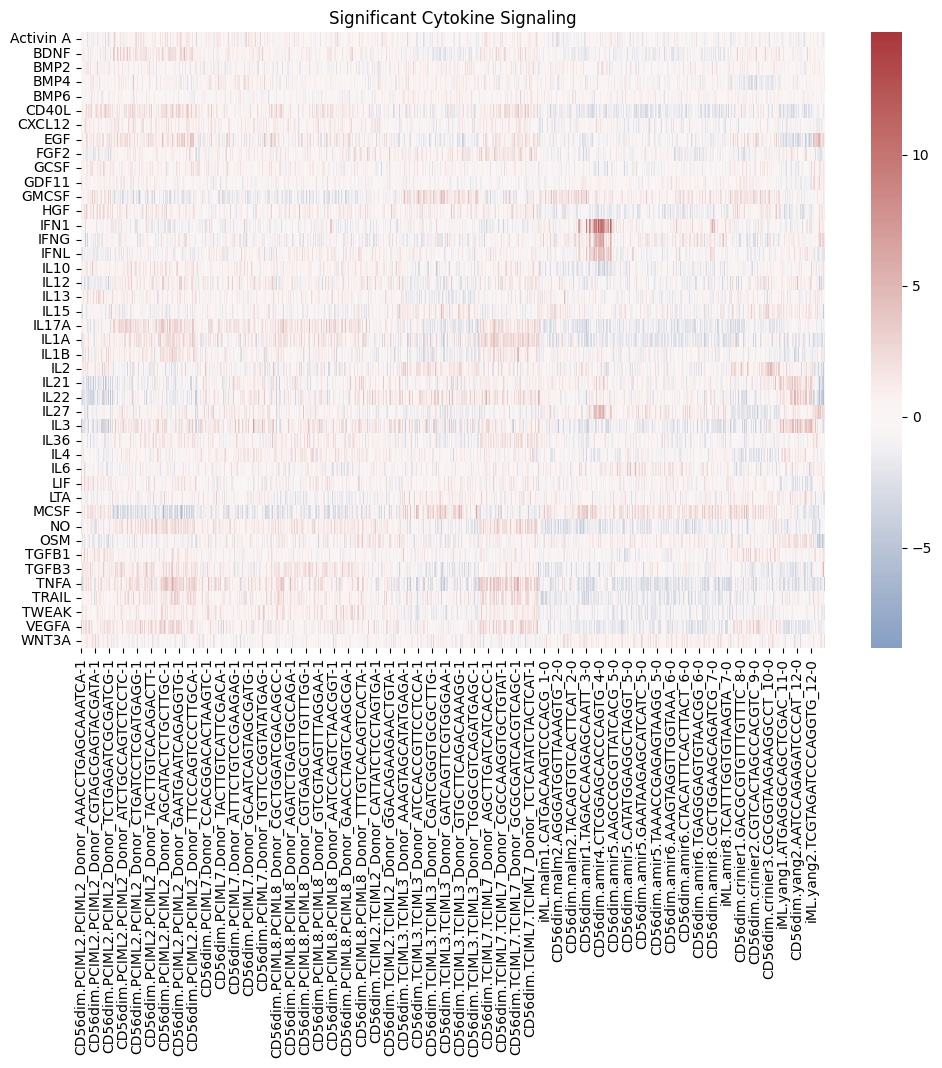

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(zscores, cmap="vlag", center=0)
plt.title("Significant Cytokine Signaling")
plt.show()

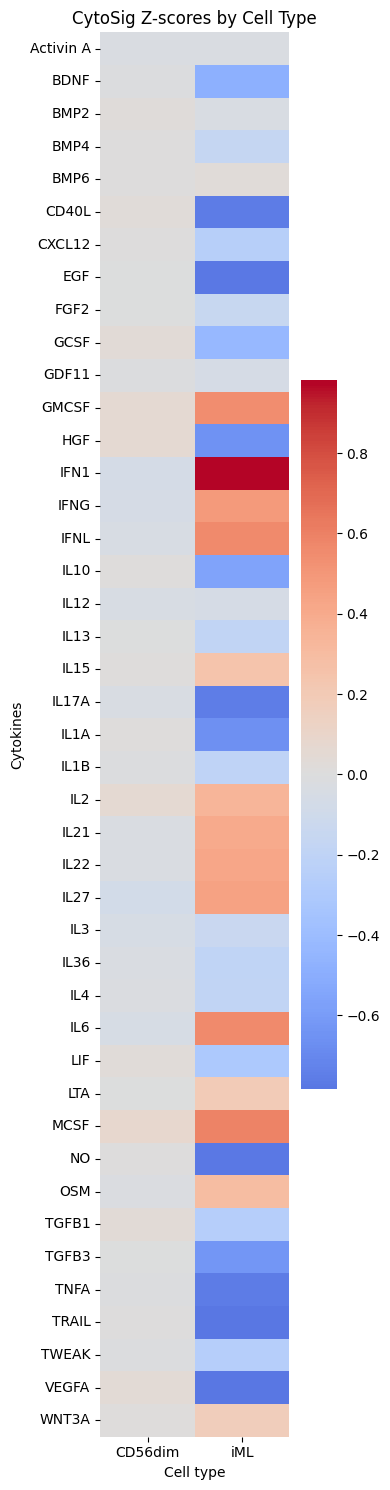

In [14]:
celltypes = [c.split('.')[0] for c in zscores.columns]
zscores_ct = zscores.T  # transpose to cells × cytokines
zscores_ct['celltype'] = celltypes

# group by cell type and compute mean
zscores_ct = zscores_ct.groupby('celltype').mean().T  # transpose back: cytokines × celltypes

plt.figure(figsize=(4, 15))
sns.heatmap(zscores_ct, cmap='coolwarm', center=0)
plt.xlabel("Cell type")
plt.ylabel("Cytokines")
plt.title("CytoSig Z-scores by Cell Type")
plt.tight_layout()
plt.show()

In [15]:
# Identify columns
iML_cols = [c for c in zscores.columns if c.startswith("iML")]
CD56dim_cols = [c for c in zscores.columns if c.startswith("CD56dim")]

print(len(iML_cols), "iML cells")
print(len(CD56dim_cols), "CD56dim cells")

4196 iML cells
54323 CD56dim cells


In [16]:
# Let's examine the column name structure more carefully
print("Sample column names:")
for i, col in enumerate(zscores.columns[:10]):
    print(f"{i+1}. {col}")

# Parse metadata from column names
def parse_cell_metadata(column_names):
    metadata = []
    for col in column_names:
        parts = col.split('.')
        if len(parts) >= 2:
            cell_type = parts[0]  # First part is cell type
            patient_id = parts[1]  # Second part is patient/sample ID
        else:
            cell_type = 'unknown'
            patient_id = 'unknown'
        
        metadata.append({
            'cell_barcode': col,
            'cell_type': cell_type,
            'patient_id': patient_id
        })
    
    return pd.DataFrame(metadata)

# Create metadata dataframe
metadata_df = parse_cell_metadata(zscores.columns)

# Check the results
print("\nMetadata summary:")
print(metadata_df.head(10))
print("\nCell type distribution:")
print(metadata_df['cell_type'].value_counts())
print("\nPatient ID distribution:")
print(metadata_df['patient_id'].value_counts())
print("\nCells per cell type per patient:")
print(metadata_df.groupby(['cell_type', 'patient_id']).size())

Sample column names:
1. CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1
2. CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1
3. CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1
4. CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCTAGGCA-1
5. CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGGCCATAG-1
6. CD56dim.PCIML2.PCIML2_Donor_AAACCTGCACCTCGTT-1
7. CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTCTTGATG-1
8. iML.PCIML2.PCIML2_Donor_AAACCTGGTGAGTGAC-1
9. CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTGTGCGTC-1
10. CD56dim.PCIML2.PCIML2_Donor_AAACCTGGTGTTCGAT-1

Metadata summary:
                                     cell_barcode cell_type patient_id
0  CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1   CD56dim     PCIML2
1  CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1   CD56dim     PCIML2
2  CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1   CD56dim     PCIML2
3  CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCTAGGCA-1   CD56dim     PCIML2
4  CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGGCCATAG-1   CD56dim     PCIML2
5  CD56dim.PCIML2.PCIML2_Donor_AAACCT

In [17]:
#calculate average cytokine activity for each cell type within each patient

In [18]:
# Prepare data for grouping
data_with_meta = zscores.T.copy()  # Transpose so cells are rows
data_with_meta['cell_type'] = metadata_df['cell_type'].values
data_with_meta['patient_id'] = metadata_df['patient_id'].values

print("Data with metadata shape:", data_with_meta.shape)
print("\nFirst few rows:")
print(data_with_meta.iloc[:3, :8])  # Show first 3 rows, 8 columns

# Group by cell type AND patient, then take the mean
mean_activities = data_with_meta.groupby(['cell_type', 'patient_id']).mean()

print("\nMean activities shape:", mean_activities.shape)
print("This means:", len(mean_activities), "groups (cell_type × patient combinations)")
print("\nGroups:")
print(mean_activities.index.tolist())

# Transpose back so cytokines are rows
mean_activities = mean_activities.T

print("\nFinal mean activities:")
print(mean_activities.head())
print("\nShape:", mean_activities.shape)

Data with metadata shape: (58519, 45)

First few rows:
                                                Activin A      BDNF      BMP2  \
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1   1.427840  2.291508  0.488954   
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1  -1.630843 -1.261056 -0.036641   
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1  -0.084695 -0.872266 -0.262386   

                                                    BMP4      BMP6     CD40L  \
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1 -0.557392 -0.705321  2.090881   
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1  0.180162 -1.489484  0.249358   
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1  2.351055 -0.580093  0.016490   

                                                  CXCL12       EGF  
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAAATCA-1  0.681787  1.820029  
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCAGGCTA-1  0.648460  0.196508  
CD56dim.PCIML2.PCIML2_Donor_AAACCTGAGCGTCTAT-1 -0.443129 -0.720073  

Mean activities shape:

In [19]:
#extract and compare cytokine activity btw iML and CD56bright across patients
iml_columns = [col for col in mean_activities.columns if col[0] == 'iML']
cd56_columns = [col for col in mean_activities.columns if col[0] == 'CD56dim']

print(f"iML : {len(iml_columns)}")
print(iml_columns)
print(f"\nCD56dim : {len(cd56_columns)}")
print(cd56_columns)

iML : 20
[('iML', '10k_PBMC_3p_nextgem_Chromium_X'), ('iML', '10x_multiome'), ('iML', 'PCIML2'), ('iML', 'PCIML7'), ('iML', 'PCIML8'), ('iML', 'TCIML2'), ('iML', 'TCIML3'), ('iML', 'TCIML7'), ('iML', 'amir1'), ('iML', 'amir4'), ('iML', 'amir5'), ('iML', 'amir6'), ('iML', 'amir8'), ('iML', 'crinier1'), ('iML', 'crinier2'), ('iML', 'crinier3'), ('iML', 'malm1'), ('iML', 'malm2'), ('iML', 'yang1'), ('iML', 'yang2')]

CD56dim : 20
[('CD56dim', '10k_PBMC_3p_nextgem_Chromium_X'), ('CD56dim', '10x_multiome'), ('CD56dim', 'PCIML2'), ('CD56dim', 'PCIML7'), ('CD56dim', 'PCIML8'), ('CD56dim', 'TCIML2'), ('CD56dim', 'TCIML3'), ('CD56dim', 'TCIML7'), ('CD56dim', 'amir1'), ('CD56dim', 'amir4'), ('CD56dim', 'amir5'), ('CD56dim', 'amir6'), ('CD56dim', 'amir8'), ('CD56dim', 'crinier1'), ('CD56dim', 'crinier2'), ('CD56dim', 'crinier3'), ('CD56dim', 'malm1'), ('CD56dim', 'malm2'), ('CD56dim', 'yang1'), ('CD56dim', 'yang2')]


In [20]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# Extract patient IDs for each cell type
iml_patients = {col[1]: col for col in iml_columns}
cd56_patients = {col[1]: col for col in cd56_columns}

# Find shared patients (patients with both cell types)
shared_patient_ids = set(iml_patients.keys()) & set(cd56_patients.keys())
print(f"Patients with both cell types: {len(shared_patient_ids)}")
print(f"Patient IDs: {sorted(shared_patient_ids)}")

Patients with both cell types: 20
Patient IDs: ['10k_PBMC_3p_nextgem_Chromium_X', '10x_multiome', 'PCIML2', 'PCIML7', 'PCIML8', 'TCIML2', 'TCIML3', 'TCIML7', 'amir1', 'amir4', 'amir5', 'amir6', 'amir8', 'crinier1', 'crinier2', 'crinier3', 'malm1', 'malm2', 'yang1', 'yang2']


In [22]:
# Create paired column lists (in matching order)
paired_iml_cols = [iml_patients[pid] for pid in sorted(shared_patient_ids)]
paired_cd56_cols = [cd56_patients[pid] for pid in sorted(shared_patient_ids)]

print(f"\nUsing {len(paired_iml_cols)} paired samples")


Using 20 paired samples


In [23]:
paired_iml_cols

[('iML', '10k_PBMC_3p_nextgem_Chromium_X'),
 ('iML', '10x_multiome'),
 ('iML', 'PCIML2'),
 ('iML', 'PCIML7'),
 ('iML', 'PCIML8'),
 ('iML', 'TCIML2'),
 ('iML', 'TCIML3'),
 ('iML', 'TCIML7'),
 ('iML', 'amir1'),
 ('iML', 'amir4'),
 ('iML', 'amir5'),
 ('iML', 'amir6'),
 ('iML', 'amir8'),
 ('iML', 'crinier1'),
 ('iML', 'crinier2'),
 ('iML', 'crinier3'),
 ('iML', 'malm1'),
 ('iML', 'malm2'),
 ('iML', 'yang1'),
 ('iML', 'yang2')]

In [24]:
paired_cd56_cols

[('CD56dim', '10k_PBMC_3p_nextgem_Chromium_X'),
 ('CD56dim', '10x_multiome'),
 ('CD56dim', 'PCIML2'),
 ('CD56dim', 'PCIML7'),
 ('CD56dim', 'PCIML8'),
 ('CD56dim', 'TCIML2'),
 ('CD56dim', 'TCIML3'),
 ('CD56dim', 'TCIML7'),
 ('CD56dim', 'amir1'),
 ('CD56dim', 'amir4'),
 ('CD56dim', 'amir5'),
 ('CD56dim', 'amir6'),
 ('CD56dim', 'amir8'),
 ('CD56dim', 'crinier1'),
 ('CD56dim', 'crinier2'),
 ('CD56dim', 'crinier3'),
 ('CD56dim', 'malm1'),
 ('CD56dim', 'malm2'),
 ('CD56dim', 'yang1'),
 ('CD56dim', 'yang2')]

In [25]:
# Paired analysis
results_paired = []

for cytokine in mean_activities.index:
    # Get paired values (same order by patient)
    iML_vals = mean_activities.loc[cytokine, paired_iml_cols].values
    CD56dim_vals = mean_activities.loc[cytokine, paired_cd56_cols].values
    
    # Remove pairs where either value is NaN
    valid_pairs = ~(np.isnan(iML_vals) | np.isnan(CD56dim_vals))
    iML_clean = iML_vals[valid_pairs]
    CD56dim_clean = CD56dim_vals[valid_pairs]
    
    # Wilcoxon signed-rank test (paired)
    stat, p = wilcoxon(iML_clean, CD56dim_clean, alternative="two-sided")

    results_paired.append({
        "cytokine": cytokine,
        "mean_iML": iML_clean.mean(),
        "mean_CD56dim": CD56dim_clean.mean(),
        "delta_mean": iML_clean.mean() - CD56dim_clean.mean(),
        "median_iML": np.median(iML_clean),
        "median_CD56dim": np.median(CD56dim_clean),
        "delta_median": np.median(iML_clean) - np.median(CD56dim_clean),
        "n_pairs": len(iML_clean),
        "pvalue": p})



In [28]:
# Create results dataframe
results_paired_df = pd.DataFrame(results_paired).set_index("cytokine")

# Apply FDR correction
results_paired_df["FDR"] = multipletests(results_paired_df["pvalue"], method="fdr_bh")[1]
results_paired_df["significant_FDR05"] = results_paired_df["FDR"] < 0.05
results_paired_df["significant_FDR10"] = results_paired_df["FDR"] < 0.10

# Sort by FDR
results_paired_df = results_paired_df.sort_values("FDR")

# Save results
#results_paired_df.to_csv('cytokine_results_PAIRED_PATIENT_LEVEL.csv')

# Print summary
print("\n" + "="*80)
print("PAIRED PATIENT-LEVEL ANALYSIS RESULTS")
print("="*80)
print(f"\nTotal cytokines tested: {len(results_paired_df)}")
print(f"Significant at FDR < 0.05: {results_paired_df['significant_FDR05'].sum()}")
print(f"Significant at FDR < 0.10: {results_paired_df['significant_FDR10'].sum()}")
print(f"Nominal p < 0.05: {(results_paired_df['pvalue'] < 0.05).sum()}")

print("\nTop 20 results:")
print(results_paired_df[['mean_iML', 'mean_CD56dim', 'delta_mean', 
                          'n_pairs', 'pvalue', 'FDR', 'significant_FDR05']].head(20))

if results_paired_df['significant_FDR05'].sum() > 0:
    print("\n" + "="*80)
    print("SIGNIFICANT CYTOKINES (FDR < 0.05)")
    print("="*80)
    sig = results_paired_df[results_paired_df['significant_FDR05']]
    print(sig[['mean_iML', 'mean_CD56dim', 'delta_mean', 'pvalue', 'FDR']])


PAIRED PATIENT-LEVEL ANALYSIS RESULTS

Total cytokines tested: 43
Significant at FDR < 0.05: 28
Significant at FDR < 0.10: 30
Nominal p < 0.05: 29

Top 20 results:
          mean_iML  mean_CD56dim  delta_mean  n_pairs    pvalue       FDR  \
cytokine                                                                    
IL6       0.501463      0.090955    0.410508       20  0.000002  0.000082   
IL2       0.314278      0.010960    0.303318       20  0.000006  0.000123   
IL21      0.289376      0.065529    0.223846       20  0.000010  0.000137   
BMP4     -0.421223     -0.154709   -0.266514       20  0.000019  0.000205   
HGF      -0.486020     -0.260708   -0.225312       20  0.000036  0.000312   
LTA       0.227995      0.066116    0.161880       20  0.000048  0.000342   
GCSF     -0.412737     -0.090393   -0.322345       20  0.000063  0.000387   
BMP2     -0.045708      0.133333   -0.179041       20  0.000105  0.000501   
IL12      0.179783     -0.164571    0.344354       20  0.000105  

In [29]:
# Get significant cytokines (FDR < 0.10)
sig_cytokines = results_paired_df[results_paired_df['significant_FDR05']].index.tolist()

# Calculate mean across all patients for each cell type
mean_iML = mean_activities.loc[sig_cytokines, paired_iml_cols].mean(axis=1)
mean_CD56dim = mean_activities.loc[sig_cytokines, paired_cd56_cols].mean(axis=1)

# Combine into 2-column dataframe
mean_comparison = pd.DataFrame({
    
    'CD56dim': mean_CD56dim,'iML': mean_iML
})

print("Mean cytokine activities across patients:")
print(mean_comparison)



Mean cytokine activities across patients:
         CD56dim       iML
IL6     0.090955  0.501463
IL2     0.010960  0.314278
IL21    0.065529  0.289376
BMP4   -0.154709 -0.421223
HGF    -0.260708 -0.486020
LTA     0.066116  0.227995
GCSF   -0.090393 -0.412737
BMP2    0.133333 -0.045708
IL12   -0.164571  0.179783
IL27    0.255095  0.438180
IFNL    0.012513  0.167230
TGFB1   0.079929 -0.161358
LIF    -0.057953 -0.249143
IL22   -0.193577  0.138348
GDF11   0.080803 -0.057121
IL15    0.238105  0.506865
IL10   -0.295460 -0.536464
MCSF    0.454720  0.070050
TWEAK  -0.399193 -0.233433
WNT3A   0.208092  0.083235
IL17A  -0.701426 -0.573858
CXCL12 -0.222995 -0.412733
IL4    -0.243850 -0.153215
TGFB3  -0.441102 -0.737822
OSM    -0.036243  0.127409
IL3    -0.259062  0.015737
EGF    -0.066007 -0.227233
IL36   -0.204155 -0.096761


In [30]:
plt.rcParams['figure.dpi'] = 600

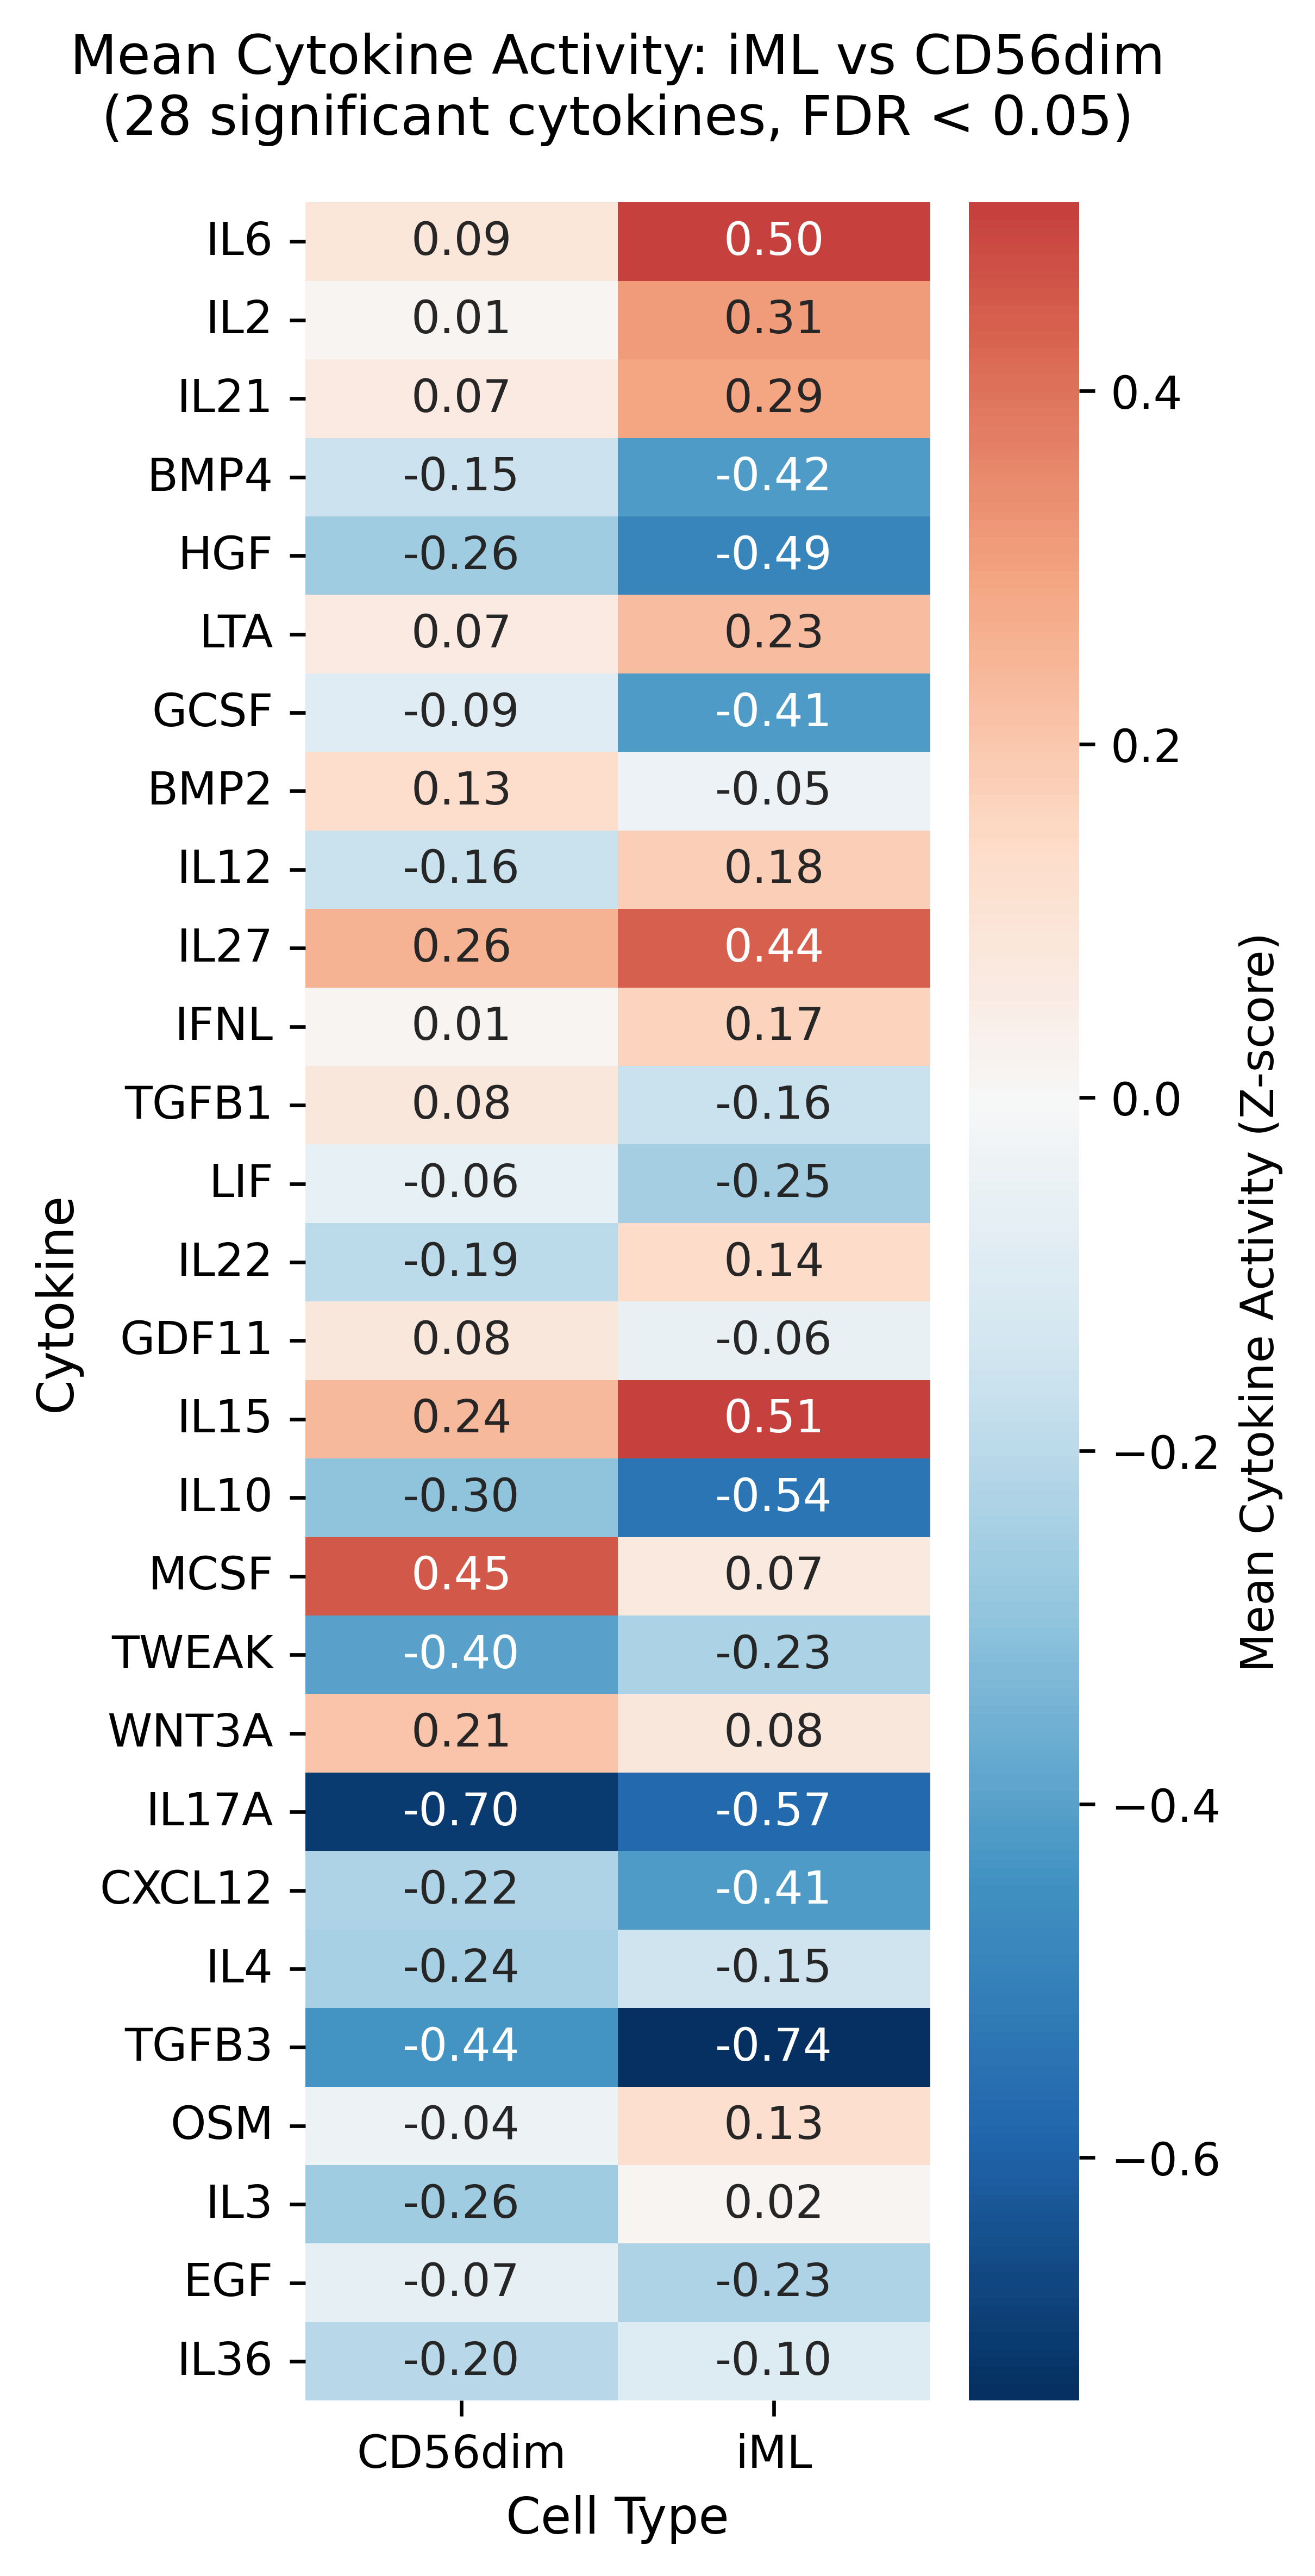

   Averaged across 20 paired patients


In [31]:
# Create heatmap
plt.figure(figsize=(4, 8))
sns.heatmap(
    mean_comparison,
    cmap='RdBu_r',
    center=0,
    annot=True,  # Show values
    fmt='.2f',   # 2 decimal places
    cbar_kws={'label': 'Mean Cytokine Activity (Z-score)'},
    linecolor='black',
    yticklabels=True,
    xticklabels=True
)

plt.title(f'Mean Cytokine Activity: iML vs CD56dim\n({len(sig_cytokines)} significant cytokines, FDR < 0.05)', 
          fontsize=12, pad=15)
plt.ylabel('Cytokine', fontsize=11)
plt.xlabel('Cell Type', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
print(f"   Averaged across {len(paired_iml_cols)} paired patients")

In [ ]:
# Selected Cytokines with biological significance and receptor gene expression

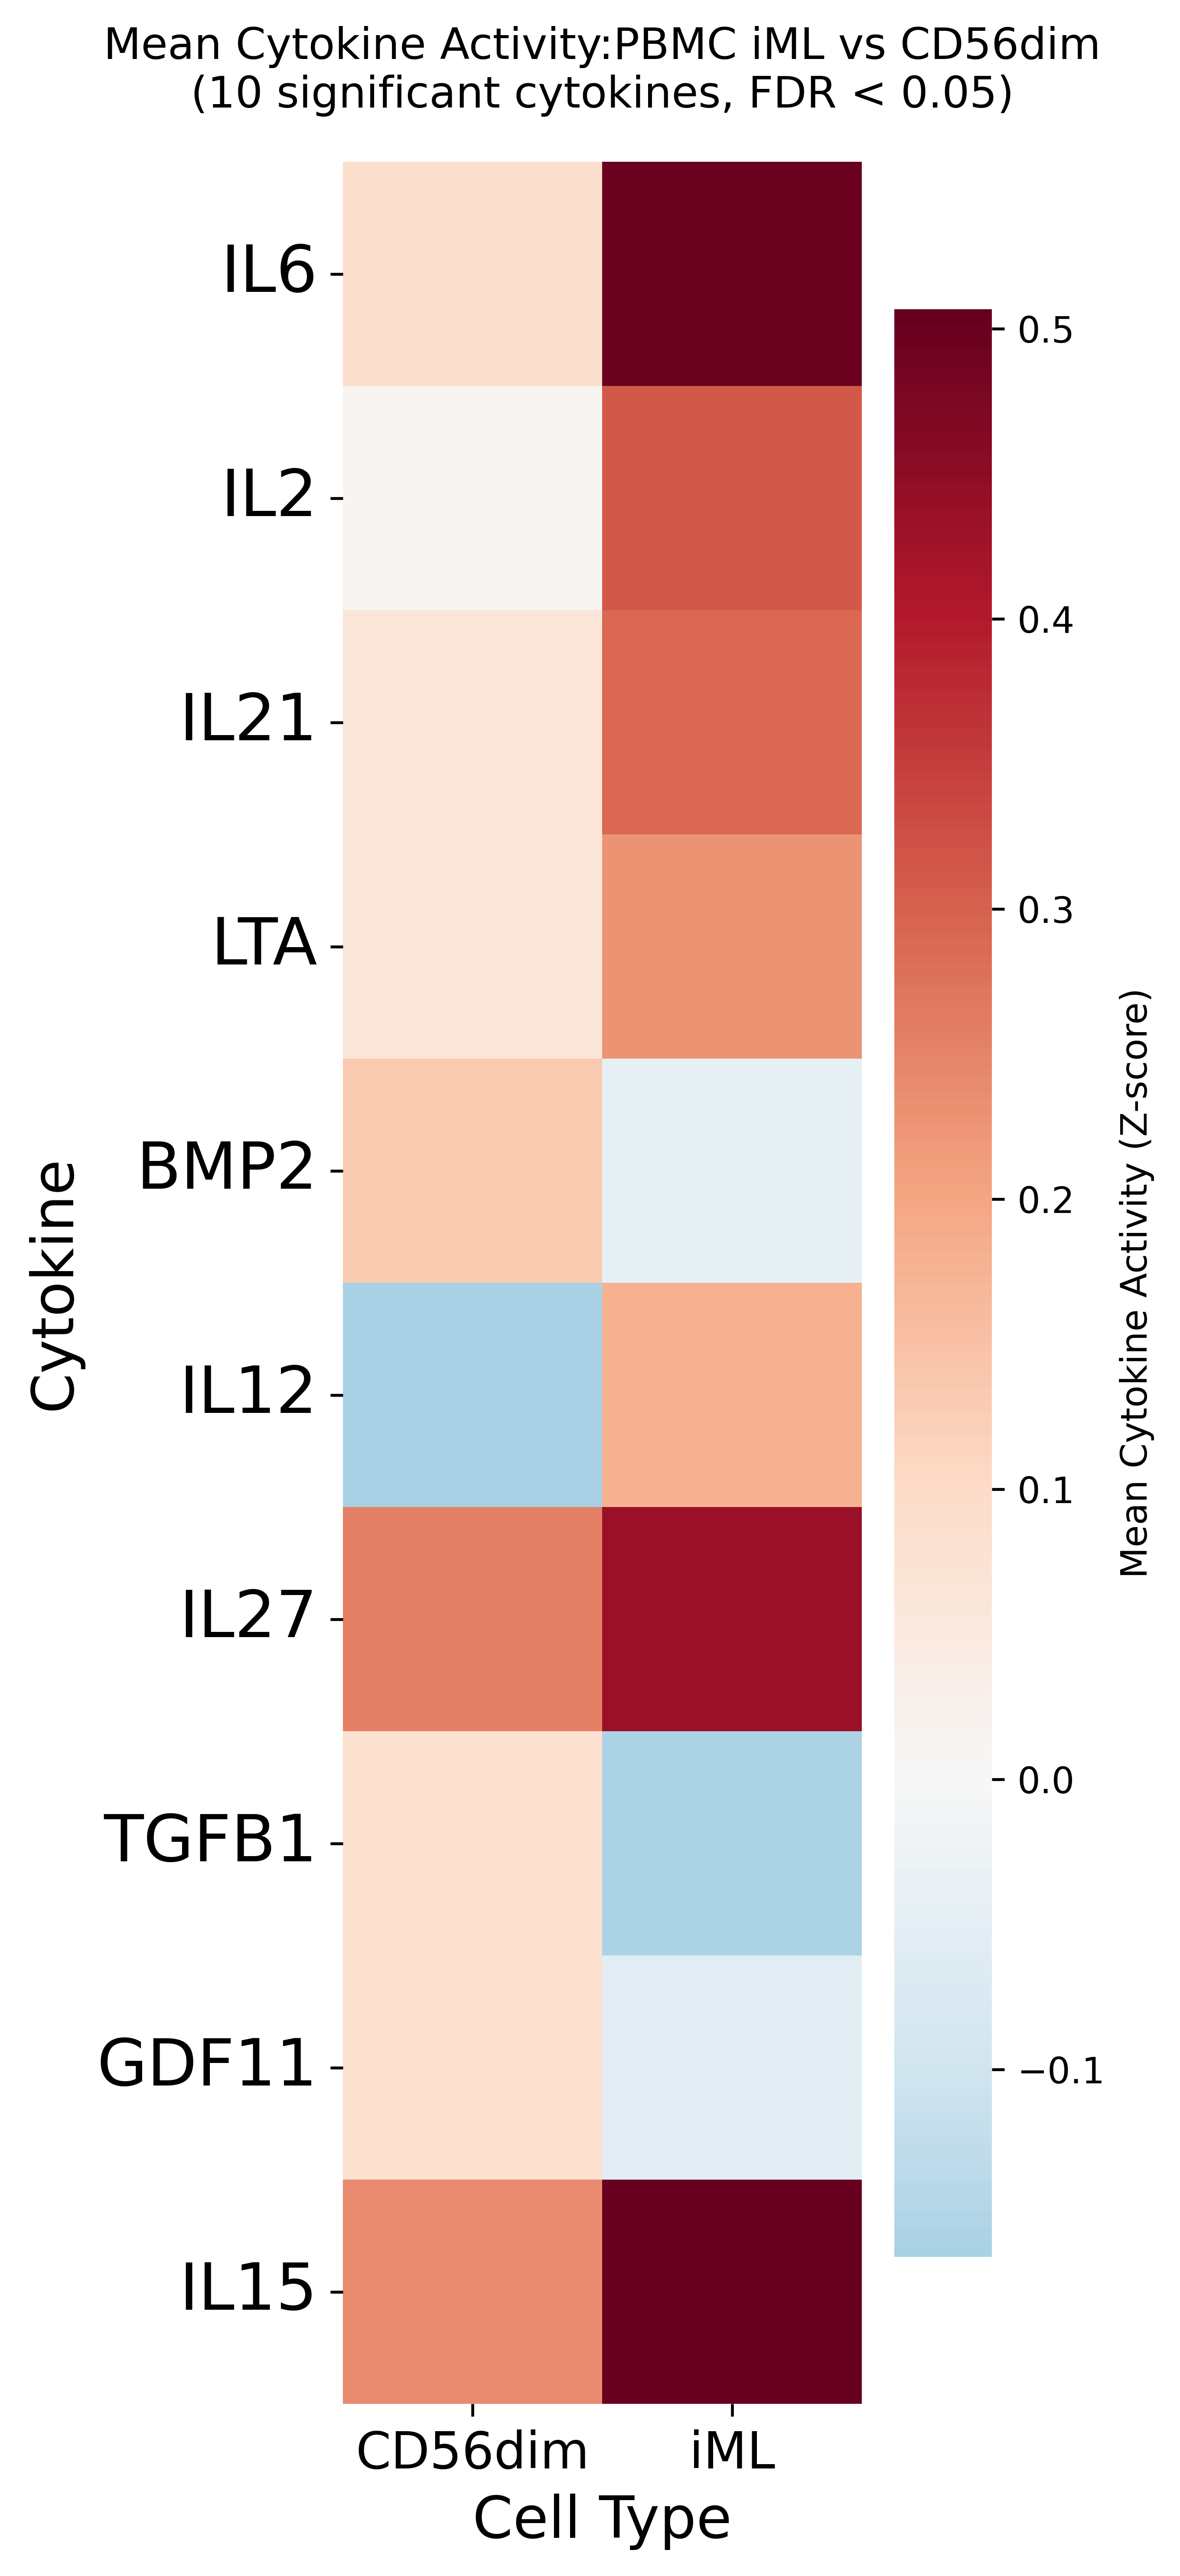

   Averaged across 20 paired patients
   Removed 18 cytokines from visualization


In [55]:
# Define cytokines to exclude
cytokines_to_remove = ['MCSF', 'IFNL', 'WNT3A', 'OSM', 'IL3', 'BMP4', 'HGF', 'GCSF', 
                       'LIF', 'IL10', 'TWEAK', 'IL17A', 'CXCL12', 'IL22',
                       'IL4', 'TGFB3', 'EGF', 'IL36']

# Filter out the specified cytokines
mean_comparison_filtered = mean_comparison[~mean_comparison.index.isin(cytokines_to_remove)]

# Update sig_cytokines count for the filtered data
remaining_cytokines = len(mean_comparison_filtered)

# Create heatmap with filtered data
plt.figure(figsize=(4.5, 10))
sns.heatmap(
    mean_comparison_filtered,  # Use filtered dataframe
    cmap='RdBu_r',
    center=0,
    #annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Mean Cytokine Activity (Z-score)'},
    linecolor='black',
    yticklabels=True,
    xticklabels=True
)

plt.title(f'Mean Cytokine Activity:PBMC iML vs CD56dim\n({remaining_cytokines} significant cytokines, FDR < 0.05)', 
          fontsize=12, pad=15)
plt.ylabel('Cytokine', fontsize=16)
plt.xlabel('Cell Type', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=18, rotation=0)
plt.tight_layout()
plt.show()
print(f"   Averaged across {len(paired_iml_cols)} paired patients")
print(f"   Removed {len(cytokines_to_remove)} cytokines from visualization")